# Final Project Plots
This notebook contains code used for creating the plots used in the final project report and presentation.
<br> <br>
*This notebook was created with the help of AI/LLM (e.g. ChatGPT, Claude)*

# Single Run Confusion Matrix

In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix

df = pd.read_csv("tornet_validation_predictions_6thrun.csv") # enter the locally saved .csv file name that you want to make the confusion matrix for

cm = confusion_matrix(df["true_label"], df["predicted_label"])

print(cm)

[[251  54]
 [ 28  18]]


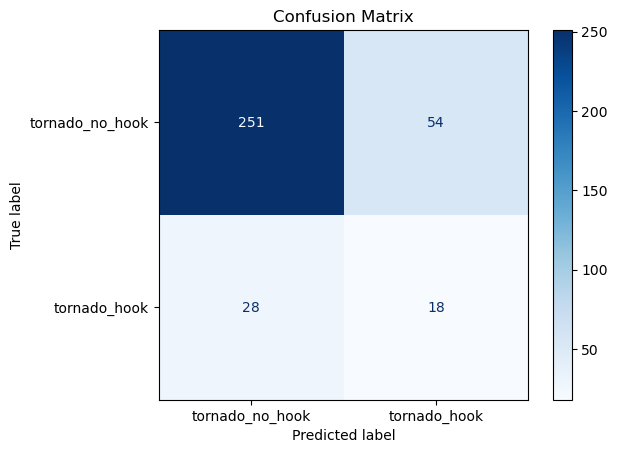

In [98]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_predictions(
    df["true_label"],
    df["predicted_label"],
    display_labels=["tornado_no_hook", "tornado_hook"],
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

# Model Summary Figures

## Combine all runs

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

files = [ # these are saved locally and the .csv names will probably be different
    "tornet_validation_predictions_2ndrun.csv",
    "tornet_validation_predictions_3rdrun.csv",
    "tornet_validation_predictions_4thrun.csv",
    "tornet_validation_predictions_5thrun.csv",
    "tornet_validation_predictions_6thrun.csv",
    "tornet_validation_predictions_7thrun.csv",
    "tornet_validation_predictions_8thrun.csv",
    "tornet_validation_predictions_9thrun.csv",
    "tornet_validation_predictions_10thrun.csv",
    "tornet_validation_predictions_11thrun.csv"
]

dfs = []

for i, f in enumerate(files):
    df = pd.read_csv(f)
    df["run"] = i + 1
    dfs.append(df)

combined = pd.concat(dfs, ignore_index=True)

## Mean Confusion Matrix

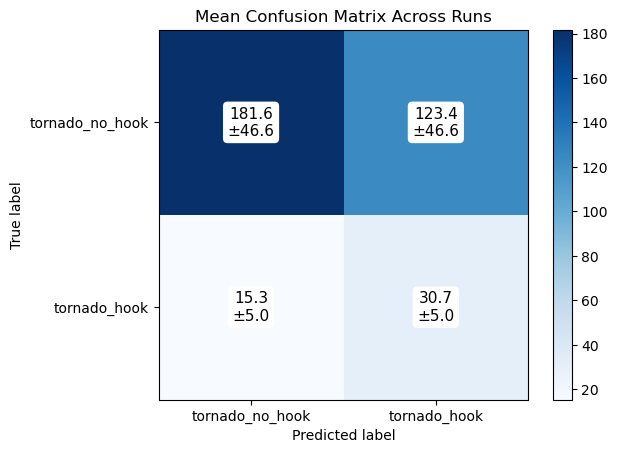

In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cms = []

for f in files:
    df = pd.read_csv(f)
    cm = confusion_matrix(df["true_label"], df["predicted_label"])
    cms.append(cm)

cms = np.array(cms)

mean_cm = cms.mean(axis=0)
std_cm = cms.std(axis=0)

fig, ax = plt.subplots()

disp = ConfusionMatrixDisplay(
    confusion_matrix=mean_cm,
    display_labels=["tornado_no_hook", "tornado_hook"]
)

# Turn off built-in numeric labels
disp.plot(cmap="Blues", ax=ax, values_format="")

# Add our own formatted labels
for i in range(mean_cm.shape[0]):
    for j in range(mean_cm.shape[1]):
        ax.text(
            j, i,
            f"{mean_cm[i,j]:.1f}\n±{std_cm[i,j]:.1f}",
            ha="center",
            va="center",
            color="black" if mean_cm[i,j] > mean_cm.max()/2 else "black",
            fontsize=11,
            bbox=dict(
                facecolor="white",   # mask color
                edgecolor="none",
                boxstyle="round,pad=0.3"
            )
        )

plt.title("Mean Confusion Matrix Across Runs")
plt.show()

## Mean ROC

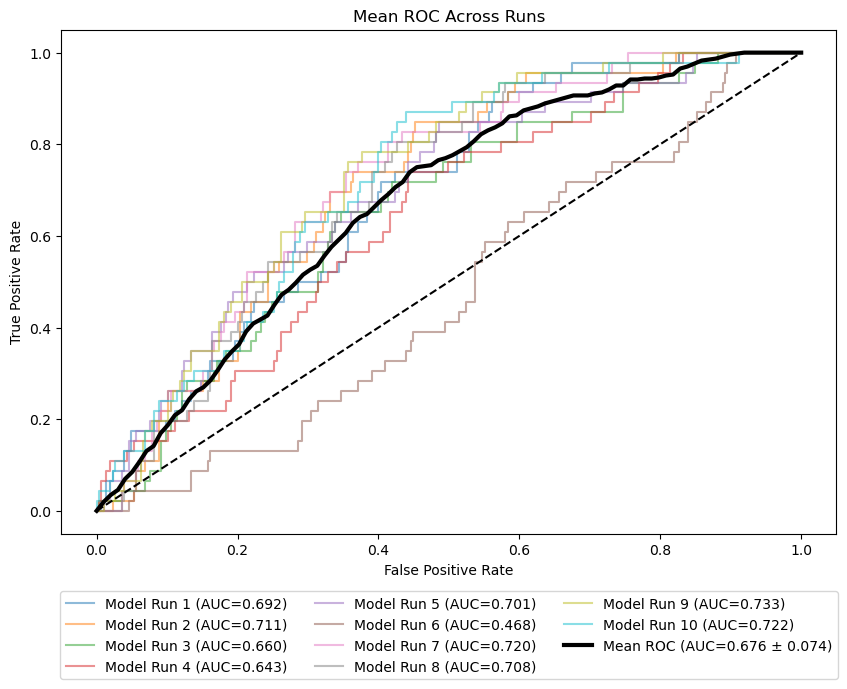

In [110]:
mean_fpr = np.linspace(0,1,100)

tprs = []
aucs = []

plt.figure(figsize=(10,8))   # make figure larger

for i, f in enumerate(files):

    df = pd.read_csv(f)

    fpr, tpr, _ = roc_curve(df["true_label"], df["hook_probability"])
    roc_auc = auc(fpr, tpr)

    aucs.append(roc_auc)

    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0
    tprs.append(interp_tpr)

    run_name = f"Model Run {i+1}"

    plt.plot(
        fpr,
        tpr,
        alpha=0.5,
        label=f"{run_name} (AUC={roc_auc:.3f})"
    )

mean_tpr = np.mean(tprs, axis=0)
mean_auc = np.mean(aucs)
std_auc = np.std(aucs)

plt.plot(
    mean_fpr,
    mean_tpr,
    linewidth=3,
    color="black",
    label=f"Mean ROC (AUC={mean_auc:.3f} ± {std_auc:.3f})"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Mean ROC Across Runs")

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3
)

plt.subplots_adjust(bottom=0.25)

plt.show()

## Probability Distribution

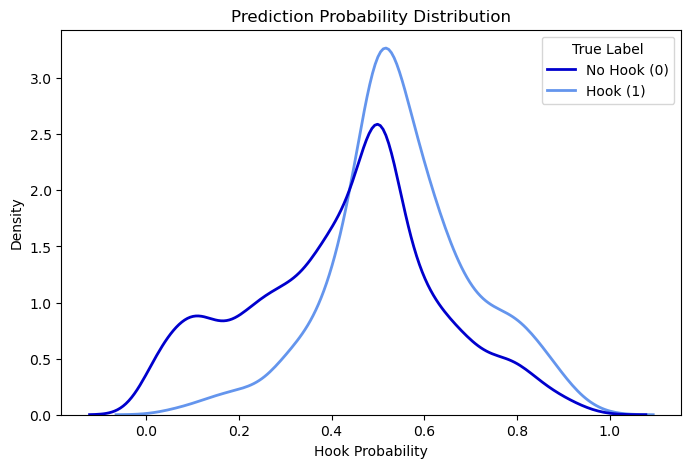

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

combined["true_label_name"] = combined["true_label"].map({
    0: "No Hook (0)",
    1: "Hook (1)"
})

plt.figure(figsize=(8,5))

ax = sns.kdeplot(
    data=combined,
    x="hook_probability",
    hue="true_label_name",
    common_norm=False,
    palette={
        "No Hook (0)": "mediumblue",
        "Hook (1)": "cornflowerblue"
    },
    linewidth=2
)

plt.title("Prediction Probability Distribution")
plt.xlabel("Hook Probability")
plt.ylabel("Density")

# Change the title of the existing legend
ax.get_legend().set_title("True Label")

plt.show()

## Case-consistency

In [104]:
case_summary = (
    combined
    .groupby(["filepath","frame_idx"])
    .agg(
        true_label=("true_label","first"),
        mean_prediction=("predicted_label","mean"),
        mean_probability=("hook_probability","mean"),
        std_probability=("hook_probability","std"),
        n_runs=("run","count")
    )
    .reset_index()
)

print(case_summary.head())

                                            filepath  frame_idx  true_label  \
0  s3://ml-cloud-project-data/tornet_2013/train/2...          3           0   
1  s3://ml-cloud-project-data/tornet_2013/train/2...          1           0   
2  s3://ml-cloud-project-data/tornet_2013/train/2...          2           0   
3  s3://ml-cloud-project-data/tornet_2013/train/2...          3           0   
4  s3://ml-cloud-project-data/tornet_2013/train/2...          1           0   

   mean_prediction  mean_probability  std_probability  n_runs  
0              0.1          0.157894         0.169084      10  
1              0.8          0.567604         0.114953      10  
2              0.8          0.569104         0.125409      10  
3              0.8          0.586339         0.140442      10  
4              0.7          0.600204         0.157713      10  


In [105]:
uncertain_cases = case_summary.sort_values("std_probability", ascending=False)

print(uncertain_cases.head(20))

                                              filepath  frame_idx  true_label  \
49   s3://ml-cloud-project-data/tornet_2014/train/2...          1           0   
149  s3://ml-cloud-project-data/tornet_2017/train/2...          3           0   
31   s3://ml-cloud-project-data/tornet_2014/train/2...          1           1   
189  s3://ml-cloud-project-data/tornet_2018/train/2...          3           0   
194  s3://ml-cloud-project-data/tornet_2019/train/2...          3           0   
111  s3://ml-cloud-project-data/tornet_2016/train/2...          0           0   
15   s3://ml-cloud-project-data/tornet_2014/train/2...          3           0   
135  s3://ml-cloud-project-data/tornet_2017/train/2...          1           0   
12   s3://ml-cloud-project-data/tornet_2014/train/2...          0           0   
13   s3://ml-cloud-project-data/tornet_2014/train/2...          1           0   
14   s3://ml-cloud-project-data/tornet_2014/train/2...          2           0   
333  s3://ml-cloud-project-d

# Plot Random Cases from Labelled Results

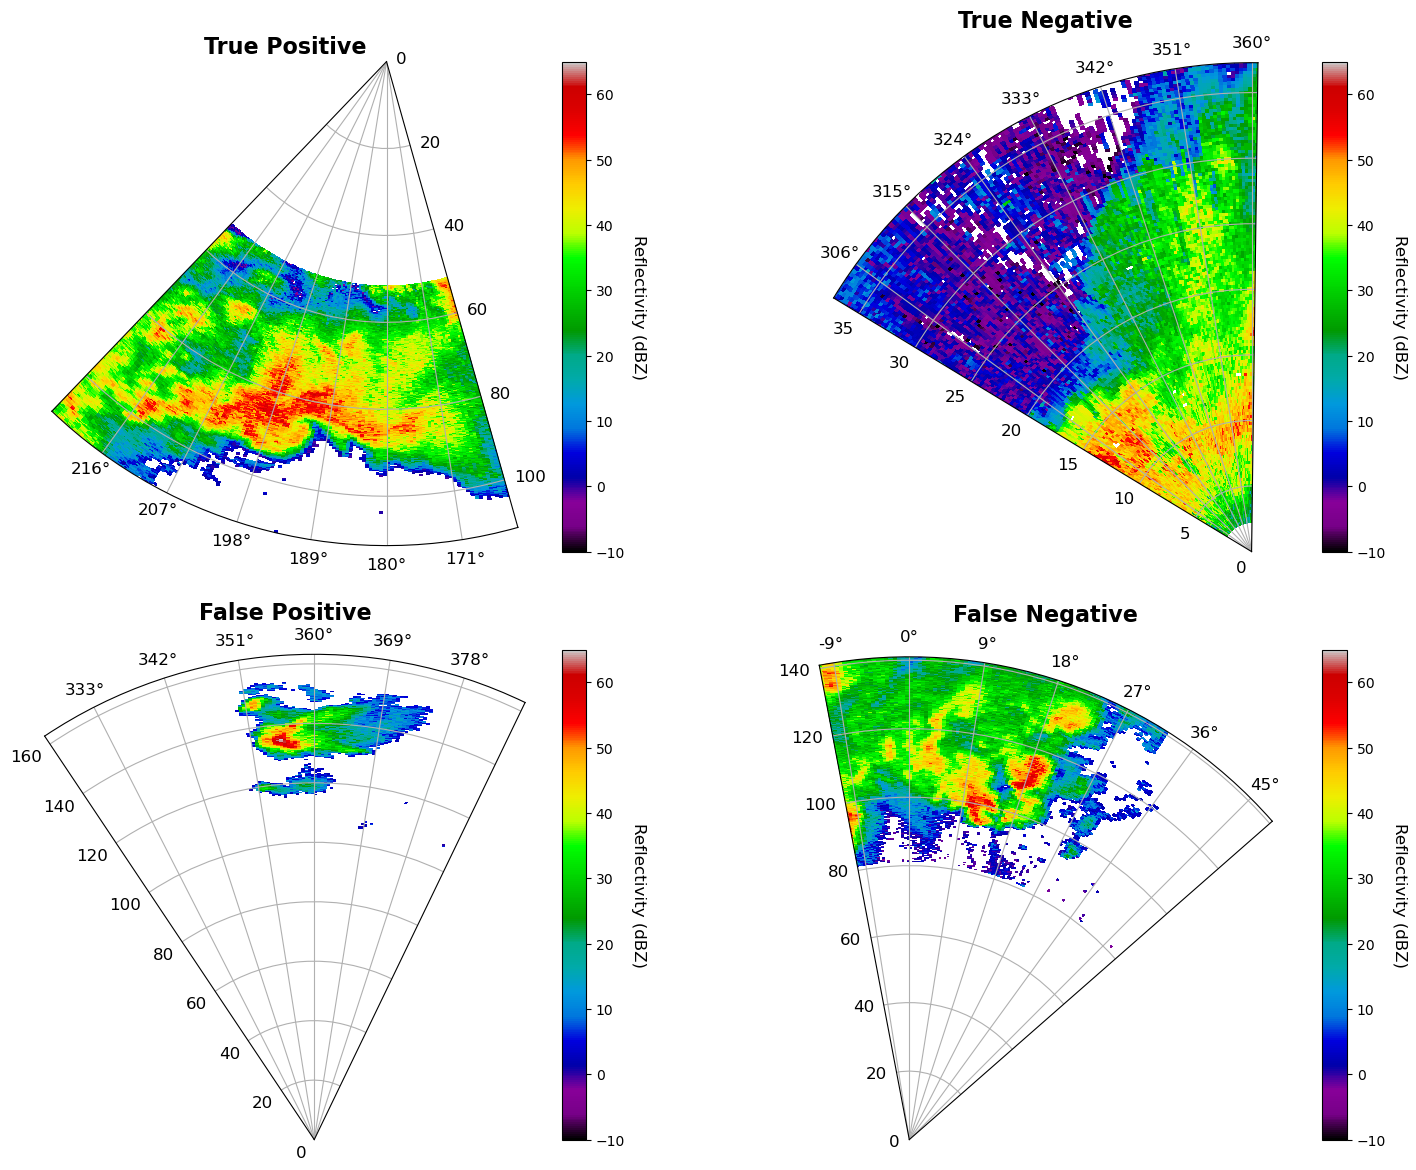

In [ ]:
import pandas as pd
import boto3
import tempfile
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import xarray as xr
import numpy as np
import pyart

# Setup S3
s3_client = boto3.client('s3')
bucket_name = 'ml-cloud-project-data'

# Load prediction CSV
df = pd.read_csv("tornet_validation_predictions_5thrun.csv") # change .csv file name for the single run to randomly select results to plot

# Split by prediction type
tp = df[(df.true_label == 1) & (df.predicted_label == 1)]
tn = df[(df.true_label == 0) & (df.predicted_label == 0)]
fp = df[(df.true_label == 0) & (df.predicted_label == 1)]
fn = df[(df.true_label == 1) & (df.predicted_label == 0)]

# Randomly sample one from each
cases = {
    "True Positive": tp.sample(1).iloc[0],
    "True Negative": tn.sample(1).iloc[0],
    "False Positive": fp.sample(1).iloc[0],
    "False Negative": fn.sample(1).iloc[0]
}

# Variables
variable = "DBZ"  # reflectivity
vmin, vmax = -10, 65
cmap = plt.get_cmap("nipy_spectral")  # vibrant rainbow
# cmap = plt.get_cmap("jet")            # classic rainbow
cbar_label = "Reflectivity (dBZ)"

# Use GridSpec for tighter layout
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(2, 2, figure=fig, wspace=0.2, hspace=0.2)

for i, (label, case) in enumerate(cases.items()):
    filepath = case["filepath"]
    frame_idx = int(case["frame_idx"])

    # Download radar file
    s3_key = filepath.replace(f"s3://{bucket_name}/", "")
    with tempfile.NamedTemporaryFile(suffix=".nc", delete=True) as tmp:
        s3_client.download_file(bucket_name, s3_key, tmp.name)
        ds = xr.open_dataset(tmp.name)
        
        # Select data: last time frame, first sweep
        data_field = ds[variable].isel(time=-1, sweep=0)
        az = np.deg2rad(ds['azimuth'].values)
        r = ds['range'].values / 1000  # km
        AZ, R = np.meshgrid(az, r)

        ax = fig.add_subplot(gs[i], polar=True)
        mesh = ax.pcolormesh(AZ, R, data_field.values.T,
                             cmap=cmap, vmin=vmin, vmax=vmax, shading='auto')

        # Configure polar plot
        ax.set_theta_zero_location('N')
        ax.set_theta_direction(-1)
        ax.set_ylim(0, r.max())
        ax.set_thetamin(np.rad2deg(az.min()))
        ax.set_thetamax(np.rad2deg(az.max()))
        ax.set_rlabel_position(225)
        ax.tick_params(axis='both', labelsize=12)

        # Add individual colorbar
        cbar = fig.colorbar(mesh, ax=ax, pad=0.05, fraction=0.046)
        cbar.set_label(cbar_label, fontsize=12, rotation=270, labelpad=15)
        cbar.ax.tick_params(labelsize=10)

        # Title
        ax.set_title(label, fontsize=16, fontweight='bold')

plt.show()